In [11]:
# ==============================
# CUSTOMER CHURN PREDICTION (FINAL PROJECT)
# ==============================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [12]:
# ==============================
# 2. LOAD DATA
# ==============================

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head(20)
df.info()
df.describe()
df['Churn'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

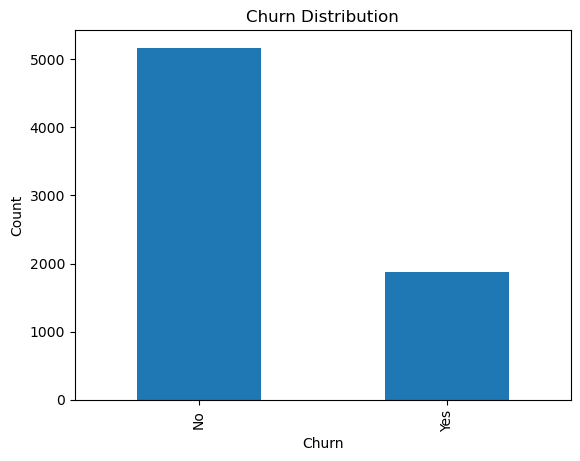

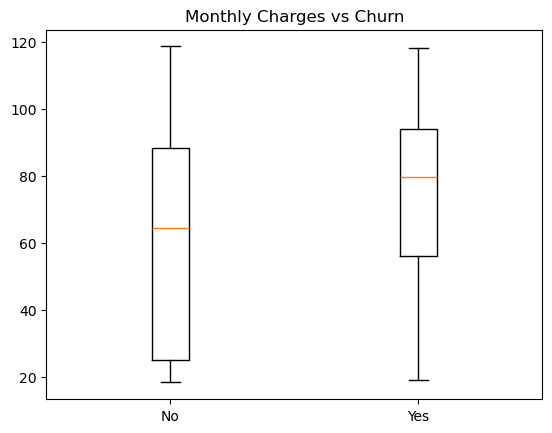

In [13]:
# ==============================
# 3. BASIC EDA (USING plt)
# ==============================

# Churn Distribution
plt.figure()
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Monthly Charges vs Churn
plt.figure()
plt.boxplot([
    df[df['Churn'] == 'No']['MonthlyCharges'],
    df[df['Churn'] == 'Yes']['MonthlyCharges']
])
plt.xticks([1,2], ['No', 'Yes'])
plt.title("Monthly Charges vs Churn")
plt.show()


In [14]:
# ==============================
# 4. DATA CLEANING
# ==============================
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

In [15]:
# ==============================
# 5. ENCODING
# ==============================
df = pd.get_dummies(df, drop_first=True)



In [16]:
# ==============================
# 6. SPLIT DATA
# ==============================
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
# ==============================
# 7. PIPELINE
# ==============================
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(solver='liblinear', class_weight='balanced'))
])



In [18]:
# ==============================
# 8. GRID SEARCH (TUNING)
# ==============================
param_grid = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [1,2,3,4,5,6,10],
    'model__max_iter': [100,200,300]
}

grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)



Best Parameters: {'model__C': 2, 'model__max_iter': 100, 'model__penalty': 'l1'}
Best CV Score: 0.7534222222222222


In [19]:
# ==============================
# 9. FINAL PREDICTION
# ==============================
y_pred = grid.predict(X_test)


In [20]:
# ==============================
# 10. EVALUATION
# ==============================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.7306325515280739

Confusion Matrix:
 [[732 301]
 [ 78 296]]

Classification Report:
               precision    recall  f1-score   support

       False       0.90      0.71      0.79      1033
        True       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



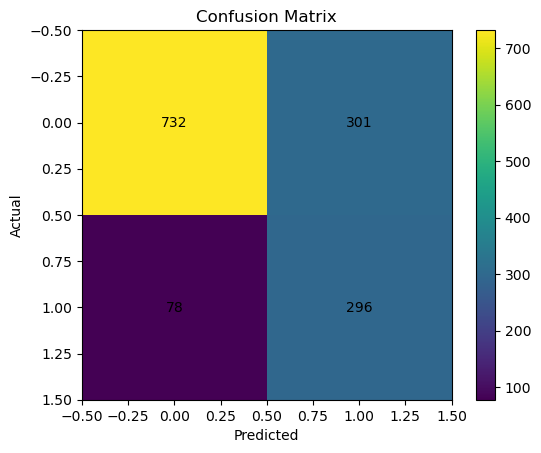

In [21]:
# ==============================
# 11. CONFUSION MATRIX PLOT
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

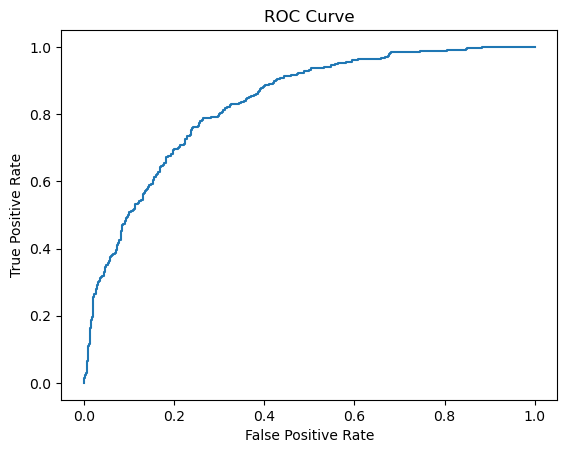

AUC Score: 0.8316828095314514


In [22]:
# ==============================
# 12. ROC CURVE
# ==============================
y_prob = grid.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

# ==============================
# END PROJECT
# ==============================